In [61]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:99% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [15]:
random.randint(140, 195)

150

In [3]:
data = []
for i in range(50):
    # 여자 데이터(키와 몸무게) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(키와 몸무게) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [28]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [65, 60, 45, 61, 68, 59, 50, 62, 59, 62, 53, 70, 66, 69, 45, 42, 69, 52, 46, 70, 43, 69, 41, 54, 60, 48, 69, 56, 44, 60, 53, 49, 51, 61, 54, 66, 59, 63, 64, 64, 43, 45, 52, 55, 42, 61, 66, 67, 55, 53]
여자 키(y축) : [162, 160, 144, 154, 160, 158, 141, 164, 160, 145, 144, 170, 156, 164, 147, 170, 145, 149, 140, 151, 168, 145, 156, 151, 165, 140, 149, 163, 162, 157, 156, 147, 144, 142, 151, 143, 142, 167, 152, 144, 160, 168, 144, 140, 153, 165, 162, 143, 142, 169]
남자 몸무게(x축) : [64, 61, 62, 91, 60, 71, 72, 93, 64, 91, 65, 95, 61, 62, 93, 88, 65, 70, 84, 72, 70, 77, 80, 78, 90, 89, 60, 61, 93, 81, 60, 87, 71, 94, 69, 61, 95, 66, 84, 75, 90, 90, 91, 94, 88, 93, 83, 82, 61, 94]
남자 키(y축) : [186, 187, 187, 169, 184, 163, 176, 179, 187, 162, 170, 174, 173, 173, 175, 160, 182, 195, 181, 163, 160, 172, 182, 190, 162, 167, 177, 166, 188, 177, 172, 162, 165, 185, 194, 175, 164, 173, 192, 167, 179, 192, 191, 177, 164, 184, 174, 179, 184, 184]


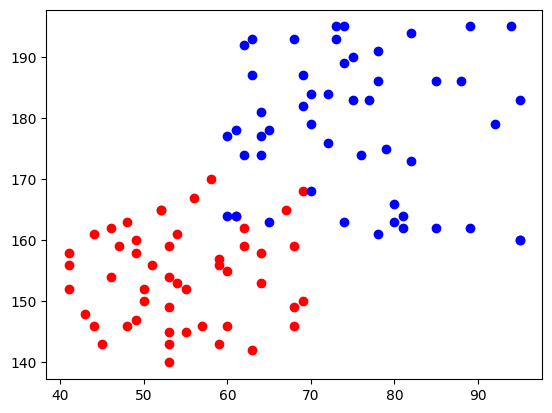

In [4]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')

plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')

# 2. 군집화 로직

In [16]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([75, 176], [66, 180])

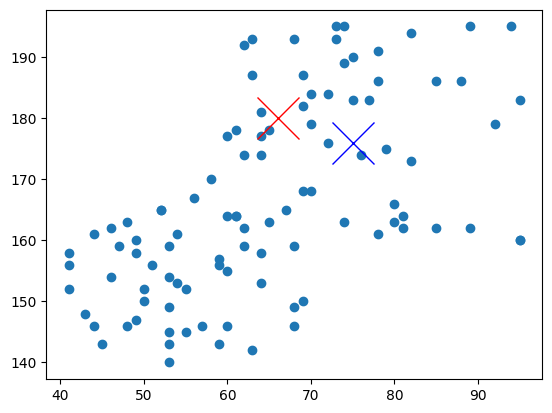

In [17]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점1

In [18]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [26]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(40, 60)

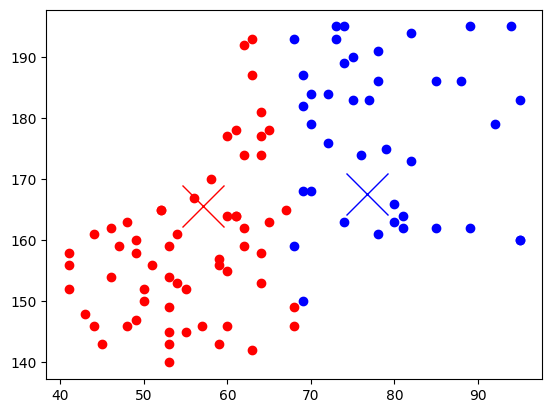

In [27]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

In [28]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[78.575, 177.45], [55.55, 159.03333333333333]]

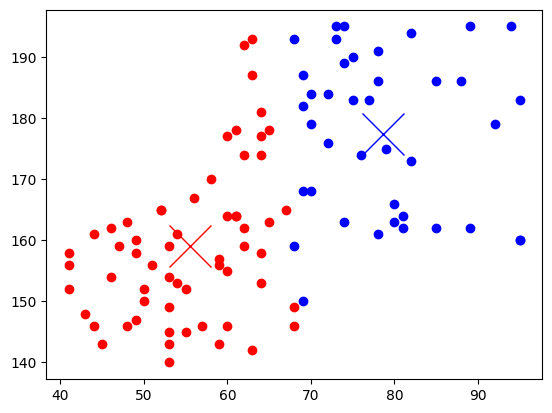

In [29]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

# 3. 군집화 전체 코드(for문 이용)
- 랜던포인트 2개 지정 - 출력 및 시각화
- for문
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤 포인트 출력 및 시각화

초기 지점 :  [[82, 164], [89, 165]]
1 번째 points : [[61.91111111111111, 164.88888888888889], [90.4, 180.0]]
2 번째 points : [[58.375, 160.51388888888889], [81.17857142857143, 181.53571428571428]]
3 번째 points : [[56.459016393442624, 157.04918032786884], [77.74358974358974, 181.02564102564102]]
4 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]
5 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]
6 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]
7 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]
8 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]
9 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]
10 번째 points : [[54.65384615384615, 154.6153846153846], [75.70833333333333, 179.16666666666666]]


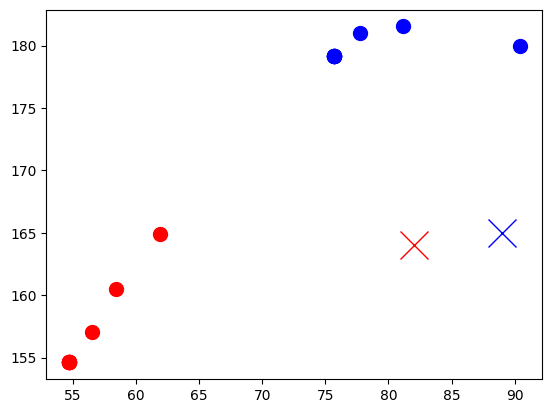

In [48]:
points = [
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)],
]
print('초기 지점 : ', points)
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)
for i in range(1, 11):
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0 = []
    group1 = []
    for d in data:
        if dist(points[0], d) < dist(points[1], d):
            group0.append(d)
        else:
            group1.append(d)
    # group0의 중간점, group1의 중감점으로 points업데이트
    meanX = np.mean([g[0] for g in group0])
    meanY = np.mean([g[1] for g in group0])
    points[0] = [meanX, meanY]
    
    meanX = np.mean([g[0] for g in group1])
    meanY = np.mean([g[1] for g in group1])
    points[1] = [meanX, meanY]
    
    # 업데이트된 points 출력 및 시각화
    print(i, '번째 points :', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=10)
plt.xlim([40,95])

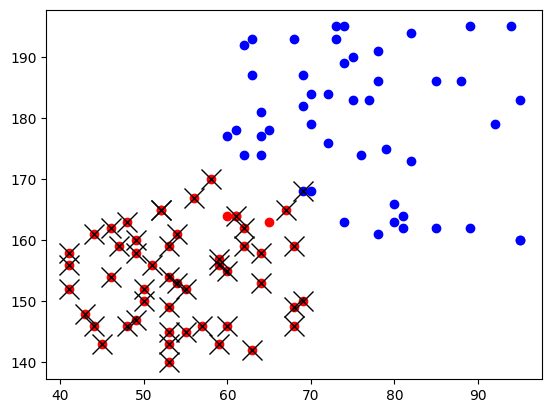

In [53]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data [::2]],
         [female[1] for female in data [::2]], 'x', color='k', markersize=15)

# 4. api(sklearn)를 이용한 군집화
- sklearn : 머신러닝 패키지
    * 예측/군집모델 : 회귀분석, 분류분석, 군집분석 - fit(학습), predict(예측, 분류
    * 변환모델 : 전처리시 사용 ex.인코딩, 스케일조정 ... - fit(학습), transform(변환함수), fit_transform(학습변환함수)

In [ ]:
# import os
# os.environ['OMP_NUM_THREADS'] = '1'
# import warnings
# warnings.filterwarnings(action='ignore') # 경고 무시

In [56]:
from sklearn.cluster import KMeans
data = np.array(data) # 원칙적으로 머신러닝 모델엔 넘파이 배열로 학습
model = KMeans(n_clusters=2, # 2개그룹으로 군집화
               init='random', # 초기포인트를 random하게
               n_init=10,    # 10번 실행
               random_state=7) # 일관적으로 모델을 생성하기 위한 seed값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [57]:
# 두 그룹의 기준점:[55.17, 156.69], [79.02, 180.5]
model.cluster_centers_

array([[ 75.70833333, 179.16666667],
       [ 54.65384615, 154.61538462]])

In [58]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [59]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

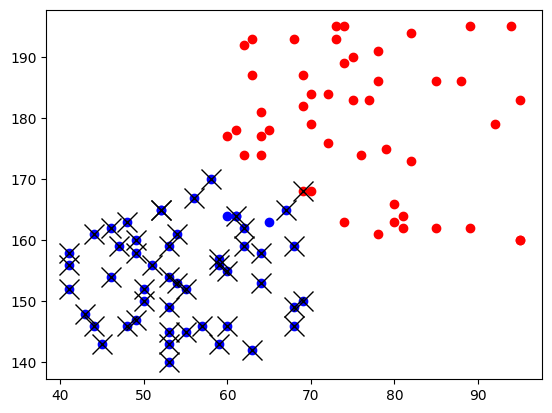

In [60]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]] , 'x', color='k', markersize=15)
plt.show()